In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn.metrics as metrics
import igraph as ig
import random as random
from GmGM import GmGM, Dataset
from MED_MAGMA import fast_kronecker_sum_model, quotient, EM_algorithm, sparse_quotient
import scanpy as sc
import anndata as ad
import pandas as pd
import warnings
ad.settings.allow_write_nullable_strings = True # sc.datasets.ebi_expression_atlas crashes if false

# Monkey-patch to get balanced_clustering package to work
class ComplexWarning(Warning):
    pass
np.core.numeric.ComplexWarning = ComplexWarning
np.VisibleDeprecationWarning = ComplexWarning

%load_ext line_profiler
%load_ext autoreload
%autoreload 2

The line_profiler extension is already loaded. To reload it, use:
  %reload_ext line_profiler
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
# Fix balanced_ami's code to work with modern numpy
# Source: https://github.com/hsmaan/balanced-clustering

from balanced_clustering.utils import (
    check_clusterings,
    contingency_matrix,
    entropy,
    mutual_info_score,
    expected_mutual_information,
    generalized_average,
    pair_confusion_matrix
)
import scipy.sparse as sp


def balanced_adjusted_mutual_info(
    labels_true, labels_pred, *, average_method="arithmetic", reweigh=True
):
    """Mutual Information adjusted for chance and balanced across true labels.
    Adjusted Mutual Information (AMI) is an adjustment of the Mutual
    Information (MI) score to account for chance. It accounts for the fact that
    the MI is generally higher for two clusterings with a larger number of
    clusters, regardless of whether there is actually more information shared.
    For two clusterings :math:`U` and :math:`V`, the AMI is given as::
        AMI(U, V) = [MI(U, V) - E(MI(U, V))] / [avg(H(U), H(V)) - E(MI(U, V))]
    This metric is independent of the absolute values of the labels:
    a permutation of the class or cluster label values won't change the
    score value in any way.
    The original AMI metric is a symmetric measure: switching :math:`U`
    (``label_true``) with :math:`V` (``labels_pred``) will return the same score value,
    but this is not the case for the reweighted and balanced AMI.
    The balanced AMI is obtained by reweighing the contingency table
    for all true label marginals, such that they sum to the same nummber,
    while preserving the total number of samples.
    Be mindful that this function is an order of magnitude slower than other
    metrics, such as the Adjusted Rand Index.
    Parameters
    ----------
    labels_true : int array, shape = [n_samples]
        A clustering of the data into disjoint subsets, called :math:`U` in
        the above formula.
    labels_pred : int array-like of shape (n_samples,)
        A clustering of the data into disjoint subsets, called :math:`V` in
        the above formula.
    average_method : str, default='arithmetic'
        How to compute the normalizer in the denominator. Possible options
        are 'min', 'geometric', 'arithmetic', and 'max'.
        .. versionadded:: 0.20
        .. versionchanged:: 0.22
           The default value of ``average_method`` changed from 'max' to
           'arithmetic'.
    reweigh : bool, default=True
        if `True`, reweighs the contingency table based on the true labels
        such that they all have equal membership. The total number of samples
        is preserved with a round-off error. If 'False', this reverts the
        balanced AMI to the original AMI implementation.
    Returns
    -------
    AMI: float (upperlimited by 1.0)
       The AMI returns a value of 1 when the two partitions are identical
       (ie perfectly matched). Random partitions (independent labellings) have
       an expected AMI around 0 on average hence can be negative. The value is
       in adjusted nats (based on the natural logarithm).
    References
    ----------
    .. [1] `Vinh, Epps, and Bailey, (2010). Information Theoretic Measures for
       Clusterings Comparison: Variants, Properties, Normalization and
       Correction for Chance, JMLR
       <http://jmlr.csail.mit.edu/papers/volume11/vinh10a/vinh10a.pdf>`_
    .. [2] `Wikipedia entry for the Adjusted Mutual Information
       <https://en.wikipedia.org/wiki/Adjusted_Mutual_Information>`_
    """
    labels_true, labels_pred = check_clusterings(labels_true, labels_pred)
    n_samples = labels_true.shape[0]
    classes = np.unique(labels_true)
    clusters = np.unique(labels_pred)
    # Special limit cases: no clustering since the data is not split.
    # This is a perfect match hence return 1.0.
    if (
        classes.shape[0] == clusters.shape[0] == 1
        or classes.shape[0] == clusters.shape[0] == 0
    ):
        return 1.0
    contingency = contingency_matrix(
        labels_true, labels_pred, reweigh=reweigh, sparse=True
    )
    # Recalculate labels_true and labels_pred if reweigh is True to
    # factor in the reweighting based on the true class frequencies.
    # These won't preserve order but this is fine since entropy is 
    # invariant to order
    if reweigh is True:
        true_sums = np.asarray(sp.csc_matrix.sum(contingency, axis=1)).ravel()
        pred_sums = np.asarray(sp.csc_matrix.sum(contingency, axis=0)).ravel()
        labels_true = np.repeat(
            np.arange(len(true_sums)), true_sums
        )
        labels_pred = np.repeat(
            np.arange(len(pred_sums)), pred_sums
        )
    contingency = contingency.astype(np.float64)
    # Calculate the MI for the two clusterings
    mi = mutual_info_score(labels_true, labels_pred, contingency=contingency)
    # Calculate the expected value for the mutual information
    emi = expected_mutual_information(contingency, n_samples)
    # Calculate entropy for each labeling
    h_true, h_pred = entropy(labels_true), entropy(labels_pred)
    normalizer = generalized_average(h_true, h_pred, average_method)
    denominator = normalizer - emi
    # Avoid 0.0 / 0.0 when expectation equals maximum, i.e a perfect match.
    # normalizer should always be >= emi, but because of floating-point
    # representation, sometimes emi is slightly larger. Correct this
    # by preserving the sign.
    if denominator < 0:
        denominator = min(denominator, -np.finfo("float64").eps)
    else:
        denominator = max(denominator, np.finfo("float64").eps)
    ami = (mi - emi) / denominator
    return ami

def balanced_adjusted_rand_index(labels_true, labels_pred, reweigh=True):
    """Rand index adjusted for chance and balanced across true labels.
    The Rand Index computes a similarity measure between two clusterings
    by considering all pairs of samples and counting pairs that are
    assigned in the same or different clusters in the predicted and
    true clusterings.
    The raw RI score is then "adjusted for chance" into the ARI score
    using the following scheme::
        ARI = (RI - Expected_RI) / (max(RI) - Expected_RI)
    The adjusted Rand index is thus ensured to have a value close to
    0.0 for random labeling independently of the number of clusters and
    samples and exactly 1.0 when the clusterings are identical (up to
    a permutation).
    The original ARI is a symmetric measure:
        adjusted_rand_score(a, b) == adjusted_rand_score(b, a)
    But this does not hold due for the balanced ARI metric.
    The balanced ARI is obtained by reweighing the contingency table
    for all true label marginals, such that they sum to the same nummber,
    while preserving the total number of samples.
    Parameters
    ----------
    labels_true : int array, shape = [n_samples]
        Ground truth class labels to be used as a reference
    labels_pred : array-like of shape (n_samples,)
        Cluster labels to evaluate
    reweigh : bool, default=True
        if `True`, reweighs the contingency table based on the true labels
        such that they all have equal membership. The total number of samples
        is preserved with a round-off error. If 'False', this reverts the
        balanced ARI to the original ARI implementation.
    Returns
    -------
    ARI : float
       Similarity score between -1.0 and 1.0. Random labelings have an ARI
       close to 0.0. 1.0 stands for perfect match.
    References
    ----------
    .. [Hubert1985] L. Hubert and P. Arabie, Comparing Partitions,
      Journal of Classification 1985
      https://link.springer.com/article/10.1007%2FBF01908075
    .. [Steinley2004] D. Steinley, Properties of the Hubert-Arabie
      adjusted Rand index, Psychological Methods 2004
    .. [wk] https://en.wikipedia.org/wiki/Rand_index#Adjusted_Rand_index
    """
    (tn, fp), (fn, tp) = pair_confusion_matrix(
        labels_true, labels_pred, reweigh=reweigh
    )
    # convert to Python integer types, to avoid overflow or underflow
    tn, fp, fn, tp = int(tn), int(fp), int(fn), int(tp)

    # Special cases: empty data or full agreement
    if fn == 0 and fp == 0:
        return 1.0

    return 2.0 * (tp * tn - fn * fp) / ((tp + fn) * (fn + tn) + (tp + fp) * (fp + tn))

In [10]:
def keep_top_k_per_row(matrix, k):
        new_matrix = np.zeros_like(matrix)
        for i in range(matrix.shape[0]):
            row = matrix[i]
            top_k_indices = np.argsort(row)[-k:]
            new_matrix[i, top_k_indices] = row[top_k_indices]
        # re-symmetrize
        new_matrix += new_matrix.T
        return new_matrix

In [ ]:
def load_and_process(dataset: dict):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        np.random.seed(0)
        dataset_name = dataset["dataset_name"]
        truth_class_name = dataset["truth_class_name"]

        # Load the data
        adata = sc.datasets.ebi_expression_atlas(dataset_name)
        num_cells, _ = adata.shape
        raw_data = adata.X.copy()

        # String-ify NA just in case
        adata.obs[truth_class_name] = adata.obs[truth_class_name].astype('category')
        adata.obs[truth_class_name] = (
            adata.obs[truth_class_name].cat.add_categories("NA").fillna("NA")
        )

        # Restrict genes to be highly variable and roughly in the same quantity as cells
        sc.pp.log1p(adata)
        sc.pp.highly_variable_genes(adata, n_top_genes=2000)
        adata.var["num_cells"] = np.asarray(np.sum(adata.X > 0, axis=0)).ravel()

        # In particular, we'll keep genes that are expressed in `percent` percent of cells,
        # where `percent` is chosen in 1% increments to yield the amount of genes
        # closest to the number of cells.
        # This way, we control for the effect of lopsidedness, while still not forcing an
        # exact #cells=#genes match by quantizing the increments.
        chosen_genes = None
        num_genes = -np.inf
        for percent in np.linspace(0, 1, 101):
            cur_chosen_genes = (
                (adata.var["num_cells"].to_numpy() > percent * adata.shape[0])
                & adata.var["highly_variable"].to_numpy()
            )
            cur_num_genes = cur_chosen_genes.sum()

            # If current choice is closer than old choice, use current choice
            if np.abs(cur_num_genes - num_cells) < np.abs(num_genes - num_cells):
                chosen_genes = cur_chosen_genes
                num_genes = cur_num_genes

        # Restrict the data to chosen genes
        for_input = raw_data[:, chosen_genes].toarray()
        adata = adata[:, chosen_genes]
        sparsity = for_input[for_input != 0].shape[0] / (for_input.shape[0]*for_input.shape[1])

        # GmGM much prefers being run on the log data, sometimes throws SVD convergence errors if it not logged
        for_input_gmgm = np.log(for_input + 1)

        ##### Run methods

        # Our robust method
        EM_results, magnitudes = EM_algorithm(
            sparse_quotient(for_input),
            max_iter=20,
            verbose=False,
            very_verbose=False,
            stop_tol=1e-7,
            return_s_values=False
        )

        # GmGM
        pure_gmgm = GmGM(
            Dataset(dataset={"data": for_input_gmgm}, structure={"data":("row", "col")}),
            threshold_method="overall",
            to_keep=1.0,
            use_nonparanormal_skeptic=False,
            n_comps=adata.shape[0]
        )
        C = pure_gmgm.precision_matrices["col"].toarray()
        R = pure_gmgm.precision_matrices["row"].toarray()
        C = C + C.T
        R = R + R.T
        pure_gmgm_results = (R, C)

        # GmGM + nonparanormal skeptic
        nonpara_gmgm = GmGM(
            Dataset(dataset={"data": for_input_gmgm}, structure={"data":("row", "col")}),
            threshold_method="overall",
            to_keep=1.0,
            use_nonparanormal_skeptic=True,
            n_comps=adata.shape[0]
        )
        C = nonpara_gmgm.precision_matrices["col"].toarray()
        R = nonpara_gmgm.precision_matrices["row"].toarray()
        C = C + C.T
        R = R + R.T
        nonpara_gmgm_results = (R, C)

        # Single axis method method
        # Performs better with rcond=1e-7 than the default of 1e-15
        basic_method = np.linalg.pinv(for_input @ for_input.T, rcond=1e-7)

        print("\t\tMethods done fitting.")
        best_em_ami = -np.inf
        best_gmgm_ami = -np.inf
        best_nonpara_ami = -np.inf
        best_basic_ami = -np.inf
        best_em_ari = -np.inf
        best_gmgm_ari = -np.inf
        best_nonpara_ari = -np.inf
        best_basic_ari = -np.inf
        best_results = {"EM": {}, "GmGM": {}, "GmGM+nonpara": {}, "Basic": {}}
        best_results["EM"]["assortativity"] = -np.inf
        best_results["GmGM"]["assortativity"] = -np.inf
        best_results["GmGM+nonpara"]["assortativity"] = -np.inf
        best_results["Basic"]["assortativity"] = -np.inf

        for k in [1, 2, 3, 4, 5, 10, 15, 20, 25, 30, 40]:
            # Post-process networks
            cell_graph_em = np.abs(EM_results[0])
            np.fill_diagonal(cell_graph_em, 0)
            gene_graph_em = np.abs(EM_results[1])
            np.fill_diagonal(cell_graph_em, 0)
            cell_graph_gmgm = np.abs(pure_gmgm_results[0])
            np.fill_diagonal(cell_graph_gmgm, 0)
            gene_graph_gmgm = np.abs(pure_gmgm_results[1])
            np.fill_diagonal(cell_graph_gmgm, 0)
            cell_graph_nonpara = np.abs(nonpara_gmgm_results[0])
            np.fill_diagonal(cell_graph_nonpara, 0)
            gene_graph_nonpara = np.abs(nonpara_gmgm_results[1])
            np.fill_diagonal(cell_graph_nonpara, 0)
            cell_graph_basic = np.abs(basic_method)
            np.fill_diagonal(cell_graph_basic, 0)

            # Keep only the top k edges per row
            adata.obsp["EM_cell_graph"] = keep_top_k_per_row(cell_graph_em, k)
            adata.varp["EM_gene_graph"] = keep_top_k_per_row(gene_graph_em, k)
            adata.obsp["GmGM_cell_graph"] = keep_top_k_per_row(cell_graph_gmgm, k)
            adata.varp["GmGM_gene_graph"] = keep_top_k_per_row(gene_graph_gmgm, k)
            adata.obsp["nonpara_cell_graph"] = keep_top_k_per_row(cell_graph_nonpara, k)
            adata.varp["nonpara_gene_graph"] = keep_top_k_per_row(gene_graph_nonpara, k)
            adata.obsp["basic_cell_graph"] = keep_top_k_per_row(cell_graph_basic, k)

            # Do multiple leiden clusterings and report the best results chosen by best AMI.
            for resolution in np.linspace(0.02, 2.0, 100):
                sc.tl.leiden(adata, key_added="leiden_EM", adjacency=adata.obsp["EM_cell_graph"] != 0, flavor="igraph", resolution=resolution, n_iterations=2)
                sc.tl.leiden(adata, key_added="leiden_GmGM", adjacency=adata.obsp["GmGM_cell_graph"] != 0, flavor="igraph", resolution=resolution, n_iterations=2)
                sc.tl.leiden(adata, key_added="leiden_nonpara", adjacency=adata.obsp["nonpara_cell_graph"] != 0, flavor="igraph", resolution=resolution, n_iterations=2)
                sc.tl.leiden(adata, key_added="leiden_basic", adjacency=adata.obsp["basic_cell_graph"] != 0, flavor="igraph", resolution=resolution, n_iterations=2)

                # Check if the AMI is better, for each model
                em_ami = balanced_adjusted_mutual_info(
                    adata.obs["leiden_EM"],
                    adata.obs[truth_class_name]
                )
                em_ari = balanced_adjusted_rand_index(
                    adata.obs["leiden_EM"],
                    adata.obs[truth_class_name]
                )
                if em_ami > best_em_ami:
                    best_em_ami = em_ami
                    best_results["EM"]["ami"] = em_ami
                    best_results["EM"]["ami_resolution"] = resolution
                if em_ari > best_em_ari:
                    best_em_ari = em_ari
                    best_results["EM"]["ari"] = em_ari
                    best_results["EM"]["ari_resolution"] = resolution

                gmgm_ami = balanced_adjusted_mutual_info(
                    adata.obs["leiden_GmGM"],
                    adata.obs[truth_class_name]
                )
                gmgm_ari = balanced_adjusted_rand_index(
                    adata.obs["leiden_GmGM"],
                    adata.obs[truth_class_name]
                )
                if gmgm_ami > best_gmgm_ami:
                    best_gmgm_ami = gmgm_ami
                    best_results["GmGM"]["ami"] = gmgm_ami
                    best_results["GmGM"]["ami_resolution"] = resolution
                if gmgm_ari > best_gmgm_ari:
                    best_gmgm_ari = gmgm_ari
                    best_results["GmGM"]["ari"] = gmgm_ari
                    best_results["GmGM"]["ari_resolution"] = resolution

                nonpara_ami = balanced_adjusted_mutual_info(
                    adata.obs["leiden_nonpara"],
                    adata.obs[truth_class_name]
                )
                nonpara_ari = balanced_adjusted_rand_index(
                    adata.obs["leiden_nonpara"],
                    adata.obs[truth_class_name]
                )
                if nonpara_ami > best_nonpara_ami:
                    best_nonpara_ami = nonpara_ami
                    best_results["GmGM+nonpara"]["ami"] = nonpara_ami
                    best_results["GmGM+nonpara"]["ami_resolution"] = resolution
                if nonpara_ari > best_nonpara_ari:
                    best_nonpara_ari = nonpara_ari
                    best_results["GmGM+nonpara"]["ari"] = nonpara_ari
                    best_results["GmGM+nonpara"]["ari_resolution"] = resolution

                basic_ami = balanced_adjusted_mutual_info(
                    adata.obs["leiden_basic"],
                    adata.obs[truth_class_name]
                )
                basic_ari = balanced_adjusted_rand_index(
                    adata.obs["leiden_basic"],
                    adata.obs[truth_class_name]
                )
                if basic_ami > best_basic_ami:
                    best_basic_ami = basic_ami
                    best_results["Basic"]["ami"] = basic_ami
                    best_results["Basic"]["ami_resolution"] = resolution
                if basic_ari > best_basic_ari:
                    best_basic_ari = basic_ari
                    best_results["Basic"]["ari"] = basic_ari
                    best_results["Basic"]["ari_resolution"] = resolution

            # Finally, let's measure the assortativity of the graph
            em_assortativity = ig.Graph.Adjacency(
                adata.obsp['EM_cell_graph'] != 0
            ).assortativity(adata.obs[truth_class_name].cat.codes.to_numpy())
            gmgm_assortativity = ig.Graph.Adjacency(
                adata.obsp['GmGM_cell_graph'] != 0
            ).assortativity(adata.obs[truth_class_name].cat.codes.to_numpy())
            nonpara_assortativity = ig.Graph.Adjacency(
                adata.obsp['nonpara_cell_graph'] != 0
            ).assortativity(adata.obs[truth_class_name].cat.codes.to_numpy())
            basic_assortativity = ig.Graph.Adjacency(
                adata.obsp['basic_cell_graph'] != 0
            ).assortativity(adata.obs[truth_class_name].cat.codes.to_numpy())

            if em_assortativity > best_results["EM"]["assortativity"]:
                best_results["EM"]["assortativity"] = em_assortativity
            if gmgm_assortativity > best_results["GmGM"]["assortativity"]:
                best_results["GmGM"]["assortativity"] = gmgm_assortativity
            if nonpara_assortativity > best_results["GmGM+nonpara"]["assortativity"]:
                best_results["GmGM+nonpara"]["assortativity"] = nonpara_assortativity
            if basic_assortativity > best_results["Basic"]["assortativity"]:
                best_results["Basic"]["assortativity"] = basic_assortativity

        results = {
            'sparsity': sparsity,
            'num_genes_kept': num_genes,
            'num_cells': num_cells,
            'num_em_iterations': len(magnitudes),
            'num_categories': len(adata.obs[truth_class_name].unique()),
            **best_results,
            **{k: v for k, v in dataset.items()}
        }

        print(f"\tCur Basic result: assort {best_results["Basic"]["assortativity"]:.3f}, ami {best_results["Basic"]["ami"]:.3f}")
        print(f"\tCur GmGM result: assort {best_results["GmGM"]["assortativity"]:.3f}, ami {best_results["GmGM"]["ami"]:.3f}")
        print(f"\tCur EM result: assort {best_results["EM"]["assortativity"]:.3f}, ami {best_results["EM"]["ami"]:.3f}")

        results_df = pd.DataFrame.from_dict({k: v for k, v in results.items() if isinstance(v, dict)}, orient="index")
        metadata = {k: v for k, v in results.items() if not isinstance(v, dict)}
        results_df = pd.concat(
            [results_df, pd.DataFrame(metadata, index=results_df.index)],
            axis=1
        )
        return results_df

In [12]:
# All HUMAN datasets in scExpressionAtlas less than 1000 cells, whose 'Experimental Factors' column
# clearly advertises a categorical feature of the cells (like cell type or cell line) which has a
# paper associated with the dataset
all_datasets = [
    {
        "dataset_name": "E-MTAB-4850",
        "truth_class_name": "Sample Characteristic[cell line]",
        "source_url": "https://www.ebi.ac.uk/gxa/sc/experiments/E-MTAB-4850/results/cell-plots",
        "paper_url": "https://europepmc.org/article/MED/26860370",
        "reported_cell_count": 60,
        "reported_truth_class": "cell line",
    },
    {
        "dataset_name": "E-MTAB-6142",
        "truth_class_name": "Sample Characteristic[cell cycle phase]",
        "source_url": "https://www.ebi.ac.uk/gxa/sc/experiments/E-MTAB-6142/results/cell-plots",
        "paper_url": "https://europepmc.org/article/MED/29045817",
        "reported_cell_count": 96,
        "reported_truth_class": "cell cycle phase",
    },
    {
        "dataset_name": "E-GEOD-36552",
        "truth_class_name": "Sample Characteristic[cell type]",
        "source_url": "https://www.ebi.ac.uk/gxa/sc/experiments/E-GEOD-36552/results/cell-plots",
        "paper_url": "https://europepmc.org/article/MED/23934149",
        "reported_cell_count": 115,
        "reported_truth_class": "cell type",
    },
    # {
    #     "dataset_name": "E-MTAB-6386",
    #     "truth_class_name": "Sample Characteristic[cell type]",
    #     "source_url": "https://www.ebi.ac.uk/gxa/sc/experiments/E-MTAB-6386/results/cell-plots",
    #     "paper_url": "NONE - EXCLUDED",
    #     "reported_cell_count": 117,
    #     "reported_truth_class": "cell type",
    # },
    {
        "dataset_name": "E-CURD-10",
        "truth_class_name": "Sample Characteristic[growth condition]",
        "source_url": "https://www.ebi.ac.uk/gxa/sc/experiments/E-CURD-10/results/cell-plots",
        "paper_url": "https://europepmc.org/article/MED/27139883",
        "reported_cell_count": 118,
        "reported_truth_class": "growth condition",
    },
    # {
    #     "dataset_name": "E-MTAB-6379",
    #     "truth_class_name": "Sample Characteristic[?]",
    #     "source_url": "https://www.ebi.ac.uk/gxa/sc/experiments/E-MTAB-6379/results/cell-plots",
    #     "paper_url": "NO PAPER: EXCLUDED",
    #     "reported_cell_count": 118,
    #     "reported_truth_class": "sampling time point",
    # },
    {
        "dataset_name": "E-GEOD-99795",
        "truth_class_name": "Factor Value[compound]",
        "source_url": "https://www.ebi.ac.uk/gxa/sc/experiments/E-GEOD-99795/results/cell-plots",
        "paper_url": "https://europepmc.org/article/MED/29233929",
        "reported_cell_count": 144,
        "reported_truth_class": "dose",
    },
    {
        "dataset_name": "E-GEOD-110499",
        "truth_class_name": "Sample Characteristic[organism part]",
        "source_url": "https://www.ebi.ac.uk/gxa/sc/experiments/E-GEOD-110499/results/cell-plots",
        "paper_url": "https://europepmc.org/article/MED/29898899",
        "reported_cell_count": 168,
        "reported_truth_class": "organism part",
    },
    {
        "dataset_name": "E-MTAB-7249",
        "truth_class_name": "Sample Characteristic[inferred cell type - authors labels]",
        "source_url": "https://www.ebi.ac.uk/gxa/sc/experiments/E-MTAB-7249/results/cell-plots",
        "paper_url": "https://europepmc.org/article/MED/32054838",
        "reported_cell_count": 192,
        "reported_truth_class": "inferred cell type - authors labels",
    },
    {
        "dataset_name": "E-MTAB-7606",
        "truth_class_name": "Sample Characteristic[phenotype]",
        "source_url": "https://www.ebi.ac.uk/gxa/sc/experiments/E-MTAB-7606/results/cell-plots",
        "paper_url": "https://europepmc.org/article/MED/30778243",
        "reported_cell_count": 209,
        "reported_truth_class": "phenotype",
    },
    {
        "dataset_name": "E-MTAB-6075",
        "truth_class_name": "Factor Value[compound]",
        "source_url": "https://www.ebi.ac.uk/gxa/sc/experiments/E-MTAB-6075/results/cell-plots",
        "paper_url": "https://europepmc.org/article/MED/31088978",
        "reported_cell_count": 236,
        "reported_truth_class": "compound",
    },
    {
        "dataset_name": "E-GEOD-124858",
        "truth_class_name": "Factor Value[passage]",
        "source_url": "https://www.ebi.ac.uk/gxa/sc/experiments/E-GEOD-124858/results/cell-plots",
        "paper_url": "https://europepmc.org/article/MED/30635013",
        "reported_cell_count": 241,
        "reported_truth_class": "passage",
    },
    {
        "dataset_name": "E-GEOD-111727",
        "truth_class_name": "Sample Characteristic[disease]",
        "source_url": "https://www.ebi.ac.uk/gxa/sc/experiments/E-GEOD-111727/results/cell-plots",
        "paper_url": "https://europepmc.org/article/MED/29694901",
        "reported_cell_count": 320,
        "reported_truth_class": "disease",
    },
    # {
    #     "dataset_name": "E-MTAB-6911",
    #     "truth_class_name": "?",
    #     "source_url": "https://www.ebi.ac.uk/gxa/sc/experiments/E-MTAB-6911/results/cell-plots",
    #     "paper_url": "NONE: EXCLUDED",
    #     "reported_cell_count": 330,
    #     "reported_truth_class": "progenitor cell type",
    # },
    {
        "dataset_name": "E-GEOD-100618",
        "truth_class_name": "Sample Characteristic[cell type]",
        "source_url": "https://www.ebi.ac.uk/gxa/sc/experiments/E-GEOD-100618/results/cell-plots",
        "paper_url": "https://europepmc.org/article/MED/29167569",
        "reported_cell_count": 414,
        "reported_truth_class": "cell type",
    },
    {
        "dataset_name": "E-MTAB-8498",
        "truth_class_name": "Sample Characteristic[cell type]",
        "source_url": "https://www.ebi.ac.uk/gxa/sc/experiments/E-MTAB-8498/results/cell-plots",
        "paper_url": "https://europepmc.org/article/MED/31845972",
        "reported_cell_count": 448,
        "reported_truth_class": "inferred cell type - authors labels",
    },
    {
        "dataset_name": "E-MTAB-9801",
        "truth_class_name": "Sample Characteristic[inferred cell type - authors labels]",
        "source_url": "https://www.ebi.ac.uk/gxa/sc/experiments/E-MTAB-9801/results/cell-plots",
        "paper_url": "https://europepmc.org/article/MED/34588693",
        "reported_cell_count": 486,
        "reported_truth_class": "inferred cell type - authors labels",
    },
    {
        "dataset_name": "E-GEOD-75688",
        "truth_class_name": "Sample Characteristic[histology]",
        "source_url": "https://www.ebi.ac.uk/gxa/sc/experiments/E-GEOD-75688/results/cell-plots",
        "paper_url": "https://europepmc.org/article/MED/28474673",
        "reported_cell_count": 520,
        "reported_truth_class": "histology",
    },
    {
        "dataset_name": "E-GEOD-86618",
        "truth_class_name": "Sample Characteristic[disease]",
        "source_url": "https://www.ebi.ac.uk/gxa/sc/experiments/E-GEOD-86618/results/cell-plots",
        "paper_url": "https://europepmc.org/article/MED/27942595",
        "reported_cell_count": 537,
        "reported_truth_class": "disease",
    },
    {
        "dataset_name": "E-GEOD-98556",
        "truth_class_name": "Sample Characteristic[cell type]",
        "source_url": "https://www.ebi.ac.uk/gxa/sc/experiments/E-GEOD-98556/results/cell-plots",
        "paper_url": "https://europepmc.org/article/MED/29230913",
        "reported_cell_count": 545,
        "reported_truth_class": "cell type",
    },
    # 589-cell dataset had no paper
    {
        "dataset_name": "E-GEOD-83139",
        "truth_class_name": "Sample Characteristic[inferred cell type - ontology labels]",
        "source_url": "https://www.ebi.ac.uk/gxa/sc/experiments/E-GEOD-83139/results/cell-plots",
        "paper_url": "https://europepmc.org/article/MED/27364731",
        "reported_cell_count": 619,
        "reported_truth_class": "inferred cell type - ontology labels",
    },
    {
        "dataset_name": "E-CURD-7",
        "truth_class_name": "Sample Characteristic[sampling site]",
        "source_url": "https://www.ebi.ac.uk/gxa/sc/experiments/E-CURD-7/results/cell-plots",
        "paper_url": "https://europepmc.org/article/MED/29795293",
        "reported_cell_count": 631,
        "reported_truth_class": "sampling site",
    },
    {
        "dataset_name": "E-ENAD-21",
        "truth_class_name": "Sample Characteristic[cell type]",
        "source_url": "https://www.ebi.ac.uk/gxa/sc/experiments/E-ENAD-21/results/cell-plots",
        "paper_url": "https://europepmc.org/article/MED/29795293",
        "reported_cell_count": 631,
        "reported_truth_class": "cell type",
    },
    {
        "dataset_name": "E-GEOD-70580",
        "truth_class_name": "Sample Characteristic[cell type]",
        "source_url": "https://www.ebi.ac.uk/gxa/sc/experiments/E-GEOD-70580/results/cell-plots",
        "paper_url": "https://europepmc.org/article/MED/26878113",
        "reported_cell_count": 648,
        "reported_truth_class": "cell type",
    },
    {
        "dataset_name": "E-ENAD-20",
        "truth_class_name": "Factor Value[time]",
        "source_url": "https://www.ebi.ac.uk/gxa/sc/experiments/E-ENAD-20/results/cell-plots",
        "paper_url": "https://europepmc.org/article/MED/30017245",
        "reported_cell_count": 667,
        "reported_truth_class": "time",
    },
    # 681-cell dataset had no paper
    {
        "dataset_name": "E-GEOD-75140",
        "truth_class_name": "Sample Characteristic[cell type]",
        "source_url": "https://www.ebi.ac.uk/gxa/sc/experiments/E-GEOD-75140/results/cell-plots",
        "paper_url": "https://europepmc.org/article/MED/26644564",
        "reported_cell_count": 734,
        "reported_truth_class": "cell type",
    },
    {
        "dataset_name": "E-CURD-6",
        "truth_class_name": "Sample Characteristic[disease]",
        "source_url": "https://www.ebi.ac.uk/gxa/sc/experiments/E-CURD-6/results/cell-plots",
        "paper_url": "https://europepmc.org/article/MED/29030335 AND https://europepmc.org/article/MED/30545929",
        "reported_cell_count": 986,
        "reported_truth_class": "disease",
    },
     {
        "dataset_name": "E-MTAB-10596",
        "truth_class_name": "Sample Characteristic[growth condition]",
        "source_url": "https://www.ebi.ac.uk/gxa/sc/experiments/E-MTAB-10596/results/cell-plots",
        "paper_url": "https://europepmc.org/article/MED/35217915",
        "reported_cell_count": 993,
        "reported_truth_class": "growth condition",
    },
]
all_datasets += [
    { # Does not advertise its categorical data on website, but nevertheless has one
        "dataset_name": "E-GEOD-75367",
        "truth_class_name": "Sample Characteristic[facs marker]",
        "source_url": "https://www.ebi.ac.uk/gxa/sc/experiments/E-GEOD-75367/results/cell-plots",
        "paper_url": "https://europepmc.org/article/MED/27556950",
        "reported_cell_count": 72,
        "reported_truth_class": "none advertised",
    },
    { # Does not advertise its categorical data on website, but nevertheless has one
        "dataset_name": "E-GEOD-81383",
        "truth_class_name": "Sample Characteristic[cell line]",
        "source_url": "https://www.ebi.ac.uk/gxa/sc/experiments/E-GEOD-81383/results/cell-plots",
        "paper_url": "https://europepmc.org/article/MED/27903987",
        "reported_cell_count": 226,
        "reported_truth_class": "none advertised",
    },
    { # Does not advertise its categorical data on website, but nevertheless has one
        "dataset_name": "E-MTAB-7381",
        "truth_class_name": "Sample Characteristic[individual]",
        "source_url": "https://www.ebi.ac.uk/gxa/sc/experiments/E-MTAB-7381/results/cell-plots",
        "paper_url": "https://europepmc.org/article/MED/30692988",
        "reported_cell_count": 287,
        "reported_truth_class": "none advertised",
    },
    { # Does not advertise its categorical data on website, but nevertheless has one
        "dataset_name": "E-GEOD-109979",
        "truth_class_name": "Factor Value[time]",
        "source_url": "https://www.ebi.ac.uk/gxa/sc/experiments/E-GEOD-109979/results/cell-plots",
        "paper_url": "https://europepmc.org/article/MED/29427839",
        "reported_cell_count": 329,
        "reported_truth_class": "none advertised",
    },

    { # Does not advertise its categorical data on website, but nevertheless has one
        "dataset_name": "E-GEOD-89232",
        "truth_class_name": "Sample Characteristic[cell type]",
        "source_url": "https://www.ebi.ac.uk/gxa/sc/experiments/E-GEOD-89232/results/cell-plots",
        "paper_url": "https://europepmc.org/article/MED/27864467",
        "reported_cell_count": 957,
        "reported_truth_class": "none advertised",
    },
]

print(len(all_datasets))

30


In [13]:
final_result =  None
for i, dataset in enumerate(all_datasets):
    print(f"Processing {dataset['dataset_name']} [{i+1} of {len(all_datasets)}]...")
    cur_result = load_and_process(dataset)
    if final_result is None:
        final_result = cur_result
    else:
        final_result = pd.concat([final_result, cur_result])

final_result

Processing E-MTAB-4850 [1 of 30]...
		Methods done fitting.
	Cur Basic result: assort 0.884, ami 0.254
	Cur GmGM result: assort 0.884, ami 1.000
	Cur EM result: assort 0.616, ami 0.706
Processing E-MTAB-6142 [2 of 30]...
		Methods done fitting.
	Cur Basic result: assort 0.037, ami 0.344
	Cur GmGM result: assort 0.037, ami 0.340
	Cur EM result: assort 0.046, ami 0.538
Processing E-GEOD-36552 [3 of 30]...
		Methods done fitting.
	Cur Basic result: assort -0.005, ami 0.376
	Cur GmGM result: assort -0.005, ami 0.564
	Cur EM result: assort 0.001, ami 0.717
Processing E-CURD-10 [4 of 30]...
		Methods done fitting.
	Cur Basic result: assort 0.012, ami 0.244
	Cur GmGM result: assort 0.117, ami 0.170
	Cur EM result: assort 0.731, ami 0.876
Processing E-GEOD-99795 [5 of 30]...
		Methods done fitting.
	Cur Basic result: assort 0.040, ami 0.295
	Cur GmGM result: assort 0.023, ami 0.075
	Cur EM result: assort 0.206, ami 0.460
Processing E-GEOD-110499 [6 of 30]...
		Methods done fitting.
	Cur Basic 

,assortativity,ami,ami_resolution,ari,ari_resolution,sparsity,num_genes_kept,num_cells,num_em_iterations,num_categories,dataset_name,truth_class_name,source_url,paper_url,reported_cell_count,reported_truth_class
EM,0.616162,0.706349,0.58,0.812264,0.58,0.849471,63,60,20,2,E-MTAB-4850,Sample Characteristic[cell line],https://www.ebi.ac.uk/gxa/sc/experiments/E-MTA...,https://europepmc.org/article/MED/26860370,60,cell line
GmGM,0.884116,1.000000,0.30,1.000000,0.30,0.849471,63,60,20,2,E-MTAB-4850,Sample Characteristic[cell line],https://www.ebi.ac.uk/gxa/sc/experiments/E-MTA...,https://europepmc.org/article/MED/26860370,60,cell line
GmGM+nonpara,0.884116,1.000000,0.30,1.000000,0.30,0.849471,63,60,20,2,E-MTAB-4850,Sample Characteristic[cell line],https://www.ebi.ac.uk/gxa/sc/experiments/E-MTA...,https://europepmc.org/article/MED/26860370,60,cell line
Basic,0.884116,0.254212,1.10,0.141804,0.04,0.849471,63,60,20,2,E-MTAB-4850,Sample Characteristic[cell line],https://www.ebi.ac.uk/gxa/sc/experiments/E-MTA...,https://europepmc.org/article/MED/26860370,60,cell line
EM,0.046149,0.538151,1.04,0.413860,0.82,0.992102,91,96,20,3,E-MTAB-6142,Sample Characteristic[cell cycle phase],https://www.ebi.ac.uk/gxa/sc/experiments/E-MTA...,https://europepmc.org/article/MED/29045817,96,cell cycle phase
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Basic,0.002151,0.130927,1.96,0.063778,0.36,0.963648,324,329,20,4,E-GEOD-109979,Factor Value[time],https://www.ebi.ac.uk/gxa/sc/experiments/E-GEO...,https://europepmc.org/article/MED/29427839,329,none advertised
EM,-0.074122,0.062703,0.74,0.022181,0.86,0.218725,926,957,11,2,E-GEOD-89232,Sample Characteristic[cell type],https://www.ebi.ac.uk/gxa/sc/experiments/E-GEO...,https://europepmc.org/article/MED/27864467,957,none advertised
GmGM,0.045973,0.133531,0.86,0.042187,0.86,0.218725,926,957,11,2,E-GEOD-89232,Sample Characteristic[cell type],https://www.ebi.ac.uk/gxa/sc/experiments/E-GEO...,https://europepmc.org/article/MED/27864467,957,none advertised
GmGM+nonpara,0.012460,0.132263,0.76,0.040755,0.72,0.218725,926,957,11,2,E-GEOD-89232,Sample Characteristic[cell type],https://www.ebi.ac.uk/gxa/sc/experiments/E-GEO...,https://europepmc.org/article/MED/27864467,957,none advertised


In [14]:
final_result.to_csv("results/all-datasets-less-than-1000-cells-results-all.csv")

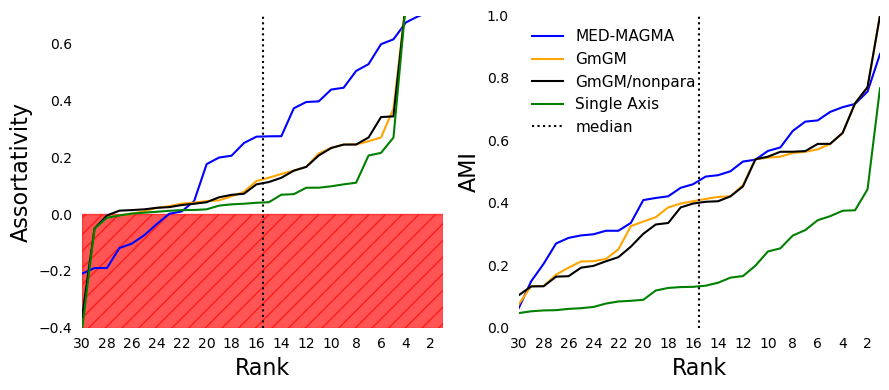

In [28]:
em_ami = final_result[final_result.index == "EM"].sort_values("ami")["ami"]
gmgm_ami = final_result[final_result.index == "GmGM"].sort_values("ami")["ami"]
nonpara_ami = final_result[final_result.index == "GmGM+nonpara"].sort_values("ami")["ami"]
basic_ami = final_result[final_result.index == "Basic"].sort_values("ami")["ami"]

em_ari = final_result[final_result.index == "EM"].sort_values("ari")["ari"]
gmgm_ari = final_result[final_result.index == "GmGM"].sort_values("ari")["ari"]
nonpara_ari = final_result[final_result.index == "GmGM+nonpara"].sort_values("ari")["ari"]
basic_ari = final_result[final_result.index == "Basic"].sort_values("ari")["ari"]

em_assortativity = final_result[final_result.index == "EM"].sort_values("assortativity")["assortativity"]
gmgm_assortativity = final_result[final_result.index == "GmGM"].sort_values("assortativity")["assortativity"]
nonpara_assortativity = final_result[final_result.index == "GmGM+nonpara"].sort_values("assortativity")["assortativity"]
basic_assortativity = final_result[final_result.index == "Basic"].sort_values("assortativity")["assortativity"]

fig, (ax, axright) = plt.subplots(figsize=(9, 4), ncols=2)

axright.plot(np.arange(len(em_ami)), em_ami, color='blue', linestyle='-', label='MED-MAGMA')
axright.plot(np.arange(len(em_ami)), gmgm_ami, color='orange', linestyle='-', label='GmGM')
axright.plot(np.arange(len(em_ami)), nonpara_ami, color='black', linestyle='-', label='GmGM/nonpara')
axright.plot(np.arange(len(em_ami)), basic_ami, color='green', linestyle='-', label='Single Axis')
ax.plot(np.arange(len(em_ami)), em_assortativity, color='blue', linestyle='-', label='MED-MAGMA')
ax.plot(np.arange(len(em_ami)), gmgm_assortativity, color='orange', linestyle='-', label='GmGM')
ax.plot(np.arange(len(em_ami)), nonpara_assortativity, color='black', linestyle='-', label='GmGM/nonpara')
ax.plot(np.arange(len(em_ami)), basic_assortativity, color='green', linestyle='-', label='Single Axis')

axright.set_ylabel("AMI", fontsize=16)
ax.set_ylabel("Assortativity", fontsize=16)


ax.set_xticks(np.arange(len(em_ami))[::2], labels=np.arange(1,len(em_ami)+1)[::-2])
axright.set_xticks(np.arange(len(em_ami))[::2], labels=np.arange(1,len(em_ami)+1)[::-2])

# Show that assortativity/ami <0 is bad
ax.set_ylim(-0.4, 0.7)
ax.axhspan(ax.get_ylim()[0], 0, color='#ff0000aa', hatch='//')
axright.set_ylim(0, 1)

for _ax in (ax, axright):
    # Median lines
    _ax.set_xlim(0, len(em_ami)-1)
    _ax.axvline((len(em_ami)-1) / 2, linestyle=':', color='black', label='median')

    # Formatting
    _ax.set_xlabel("Rank", fontsize=16)
    _ax.spines['top'].set_visible(False)
    _ax.spines['right'].set_visible(False)
    _ax.spines['left'].set_visible(False)
    _ax.spines['bottom'].set_visible(False)
    _ax.tick_params(left=False, bottom=False)

axright.legend(fontsize=11, frameon=False)

fig.tight_layout()
fig.savefig('./figures/systematic.pdf')

In [ ]:
# There are 30 datasets; numbering them 0 to 29, the median could either be #14 or #15
median_df = final_result[final_result.index=="EM"].sort_values(by="assortativity").iloc[14:16]
median_df

,assortativity,ami,ami_resolution,ari,ari_resolution,sparsity,num_genes_kept,num_cells,num_em_iterations,num_categories,dataset_name,truth_class_name,source_url,paper_url,reported_cell_count,reported_truth_class
EM,0.273098,0.295656,1.24,0.230565,1.06,0.887666,231,236,20,3,E-MTAB-6075,Factor Value[compound],https://www.ebi.ac.uk/gxa/sc/experiments/E-MTA...,https://europepmc.org/article/MED/31088978,236,compound
EM,0.274372,0.577335,0.76,0.487025,0.76,0.707465,185,185,20,7,E-MTAB-7249,Sample Characteristic[inferred cell type - aut...,https://www.ebi.ac.uk/gxa/sc/experiments/E-MTA...,https://europepmc.org/article/MED/32054838,192,inferred cell type - authors labels
